# Receive-array corrections

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/mrutils/blob/main/examples/coils.ipynb)

`noise_prewhiten` and `coil_compress`: making the noise of an array white
before anything is estimated from it, and reducing its channel count to what
the measurement actually carries.

In [1]:
try:
    import mrutils  # noqa: F401
except ImportError:
    %pip install -q "mrutils[torch]" matplotlib

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import mrutils as mru


def phantom(n=128):
    """A Shepp-Logan phantom on an n x n grid."""
    y, x = np.mgrid[-1 : 1 : n * 1j, -1 : 1 : n * 1j]
    ellipses = [
        # value, centre x, centre y, semi-axis a, semi-axis b, degrees
        (1.0, 0.0, 0.0, 0.69, 0.92, 0),
        (-0.8, 0.0, -0.0184, 0.6624, 0.874, 0),
        (-0.2, 0.22, 0.0, 0.11, 0.31, -18),
        (-0.2, -0.22, 0.0, 0.16, 0.41, 18),
        (0.1, 0.0, 0.35, 0.21, 0.25, 0),
        (0.1, 0.0, 0.1, 0.046, 0.046, 0),
        (0.1, 0.0, -0.1, 0.046, 0.046, 0),
        (0.1, -0.08, -0.605, 0.046, 0.023, 0),
        (0.1, 0.0, -0.606, 0.023, 0.023, 0),
        (0.1, 0.06, -0.605, 0.023, 0.046, 0),
    ]
    image = np.zeros((n, n))
    for value, cx, cy, a, b, degrees in ellipses:
        angle = np.deg2rad(degrees)
        xr = (x - cx) * np.cos(angle) + (y - cy) * np.sin(angle)
        yr = -(x - cx) * np.sin(angle) + (y - cy) * np.cos(angle)
        image[(xr / a) ** 2 + (yr / b) ** 2 <= 1.0] += value
    return image


n, n_coils = 96, 32
image = phantom(n).astype(complex)

# A ring of receive coils: a smooth magnitude falling away from each element,
# and a phase that rotates with its position.
y, x = np.mgrid[-1 : 1 : n * 1j, -1 : 1 : n * 1j]
angles = np.linspace(0.0, 2 * np.pi, n_coils, endpoint=False)
maps = np.stack(
    [
        np.exp(-((x - 1.3 * np.cos(a)) ** 2 + (y - 1.3 * np.sin(a)) ** 2) / 1.2)
        * np.exp(1j * 0.8 * (x * np.cos(a) + y * np.sin(a)))
        for a in angles
    ]
)
maps /= np.sqrt((np.abs(maps) ** 2).sum(0))
kspace = mru.fftc(maps * image)
print(kspace.shape)

(32, 96, 96)


## Prewhitening

Neighbouring elements of a receive array see each other, so their noise is
correlated and unequally scaled. Every estimator downstream — a SENSE solve, a
coil combination, a compression — assumes it is not. A noise-only scan
measures the covariance, and prewhitening is the change of basis that makes it
the identity.

The array below is deliberately badly behaved: neighbouring elements are
strongly coupled and the channel gains span a factor of three.

In [3]:
rng = np.random.default_rng(0)
coupling = 0.55 * np.exp(
    -np.abs(np.subtract.outer(np.arange(n_coils), np.arange(n_coils))) / 1.5
)
np.fill_diagonal(coupling, np.linspace(0.6, 1.8, n_coils))


def coloured(shape):
    white = rng.normal(size=(n_coils, *shape)) + 1j * rng.normal(size=(n_coils, *shape))
    return np.tensordot(coupling, white / np.sqrt(2), axes=(1, 0))


noise_scan = coloured((4096,))
measured = kspace + 0.01 * coloured((n, n))

whitened = mru.noise_prewhiten(measured, noise_scan, coil_axis=0)
whitened_noise = mru.noise_prewhiten(noise_scan, noise_scan, coil_axis=0)


def covariance(data):
    return np.cov(data.reshape(n_coils, -1))


def coupling_level(matrix):
    off = np.abs(matrix - np.diag(np.diag(matrix))).max()
    return off / np.abs(np.diag(matrix)).mean()


before, after = covariance(noise_scan), covariance(whitened_noise)
print("worst off-diagonal, relative to the mean channel variance:")
print(f"  before {coupling_level(before):.2f}   after {coupling_level(after):.1e}")
print(f"channel variance after: {np.diag(after).real.min():.3f} to "
      f"{np.diag(after).real.max():.3f}")

worst off-diagonal, relative to the mean channel variance:
  before 0.65   after 1.0e-03
channel variance after: 0.999 to 1.000


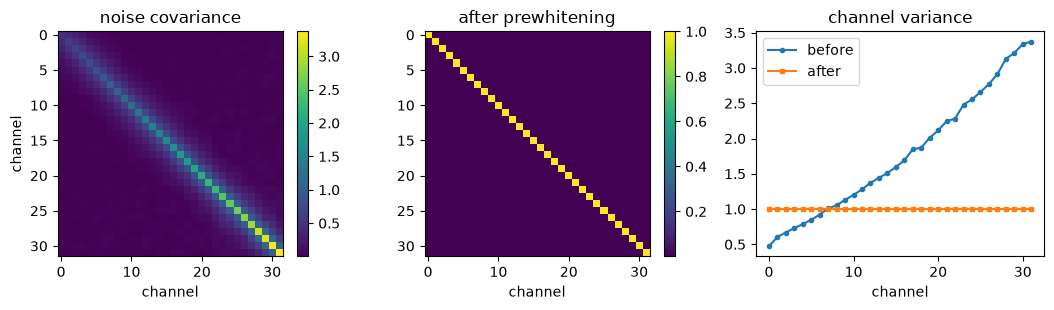

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for axis, matrix, title in (
    (axes[0], before, "noise covariance"),
    (axes[1], after, "after prewhitening"),
):
    shown = axis.imshow(np.abs(matrix), cmap="viridis")
    axis.set_title(title)
    axis.set_xlabel("channel")
    fig.colorbar(shown, ax=axis, fraction=0.046)
axes[0].set_ylabel("channel")

axes[2].plot(np.diag(before).real, "o-", markersize=3, label="before")
axes[2].plot(np.diag(after).real, "s-", markersize=3, label="after")
axes[2].set_title("channel variance")
axes[2].set_xlabel("channel")
axes[2].legend()
fig.tight_layout()

In [5]:
# Written only when the notebook runs inside a clone, and it is what the
# README shows -- so the figure in the README is always this cell's output.
figures = Path("figures")
if figures.is_dir():
    fig.savefig(figures / "coils.png", dpi=110, bbox_inches="tight")

## Compression

The elements of an array overlap, so their measurements do too: the singular
values of the channel-by-sample matrix fall away long before the channel count
does. Compression keeps the leading virtual channels and discards the rest,
which is what makes a 48-channel scan solvable at the size of an 8-channel one.

What it discards is mostly noise, so the error below is measured against the
*noiseless* combination rather than against the measurement. Against the
measurement, throwing noise away would score as a loss.

`coil_compress` returns the basis as well as the compressed data, so whatever
arrives after the calibration — later acquisitions, and the sensitivities they
are solved against — is compressed the same way.

In [6]:
flat = whitened.reshape(n_coils, -1)
values = np.linalg.svd(flat - flat.mean(axis=1, keepdims=True), compute_uv=False)

# The object as a noiseless array would have seen it.
noiseless = mru.noise_prewhiten(kspace, noise_scan, coil_axis=0)
truth = np.sqrt((np.abs(mru.ifftc(noiseless)) ** 2).sum(0))

errors, images = [], {}
for keep in range(1, n_coils + 1):
    compressed, _ = mru.coil_compress(flat, keep)
    combined = np.sqrt((np.abs(mru.ifftc(compressed.reshape(keep, n, n))) ** 2).sum(0))
    errors.append(float(np.linalg.norm(combined - truth) / np.linalg.norm(truth)))
    images[keep] = combined

best = int(np.argmin(errors)) + 1
print(f"all {n_coils} channels:   {errors[-1]:.3f}")
print(f"{best} virtual channels: {errors[best - 1]:.3f}  (the minimum)")

# A fraction asks for the channels carrying that much of the energy.
_, basis = mru.coil_compress(flat, 0.9)
print(f"0.9 of the energy is {basis.shape[0]} channels; the basis is {basis.shape}")

all 32 channels:   0.362
3 virtual channels: 0.124  (the minimum)
0.9 of the energy is 13 channels; the basis is (13, 32)


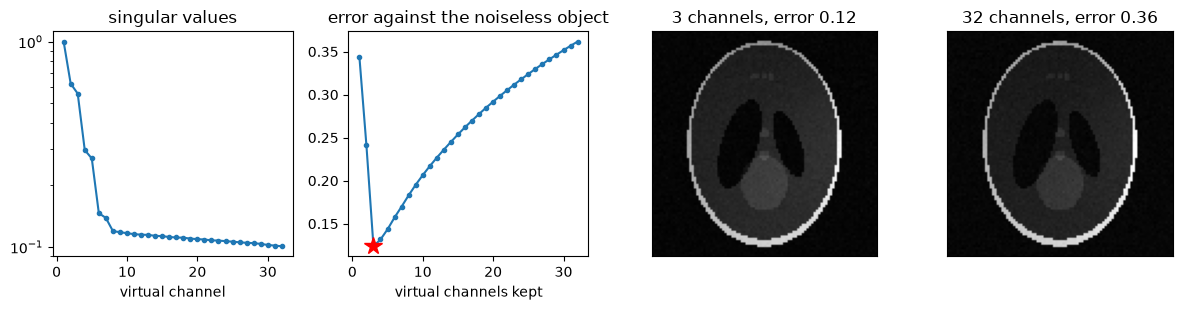

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
axes[0].semilogy(np.arange(1, n_coils + 1), values / values[0], "o-", markersize=3)
axes[0].set_title("singular values")
axes[0].set_xlabel("virtual channel")

axes[1].plot(np.arange(1, n_coils + 1), errors, "o-", markersize=3)
axes[1].plot(best, errors[best - 1], "r*", markersize=13)
axes[1].set_title("error against the noiseless object")
axes[1].set_xlabel("virtual channels kept")

for axis, keep in ((axes[2], best), (axes[3], n_coils)):
    axis.imshow(images[keep], cmap="gray", vmax=truth.max())
    axis.set_title(f"{keep} channels, error {errors[keep - 1]:.2f}")
    axis.set_xticks([])
    axis.set_yticks([])
fig.tight_layout()